### Langkah 1: Persediaan Git dan GitHub
 Membuka github dan membuat repositori baru

### Langkah 2: Import Library dan Semakan Peranti
Mengimport library yang diperlukan

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

PyTorch version: 2.11.0+cpu
Device: cpu


### Langkah 3: Muatkan dan Semak Dataset MNIST


Training data: 60000
Testing data: 10000
Image shape: torch.Size([1, 28, 28])
Actual label: 7


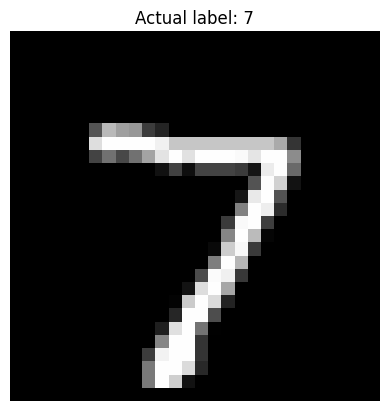

In [22]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Bina DataLoader dengan batch_size 64
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Paparkan bilangan data
print(f"Training data: {len(train_dataset)}")
print(f"Testing data: {len(test_dataset)}")

# Ambil satu imej daripada testing dataset dan paparkan
image, label = test_dataset[0]
print(f"Image shape: {image.shape}")
print(f"Actual label: {label}")

plt.imshow(image.squeeze().numpy(), cmap='gray')
plt.title(f"Actual label: {label}")
plt.axis('off')
plt.show()

### Langkah 4: Bina Model ANN (Artificial Neural Network)
Model ANN dibina menggunakan `nn.Module.

In [23]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.flatten = nn.Flatten(start_dim=1)
        self.fc1 = nn.Linear(28 * 28, 256) # Hidden layer
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 10)      # Output layer

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

ann_model = ANN().to(device)
print("Struktur Model ANN:")
print(ann_model)

# Tetapkan Loss dan Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ann_model.parameters(), lr=0.001)

Struktur Model ANN:
ANN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


### Langkah 5: Latihan dan Pengujian ANN
Model ANN dilatih selama 2 epoch.

In [16]:
# Latihan ANN
epochs = 2
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = ann_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

# Uji ANN
ann_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = ann_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

ann_accuracy = 100 * correct / total
print(f"ANN Testing Accuracy: {ann_accuracy:.2f}%")

Epoch 1/2 - Loss: 0.2991
Epoch 2/2 - Loss: 0.1252
ANN Testing Accuracy: 97.05%


### Langkah 6: Bina Model CNN (Convolutional Neural Network)


In [17]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        # Selepas pool: 28/2 = 14. Saiz tensor: 32 * 14 * 14
        self.fc1 = nn.Linear(32 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

cnn_model = CNN().to(device)
print("Struktur Model CNN:")
print(cnn_model)

# Semak saiz tensor selepas pooling (Contoh output)
dummy_input = torch.randn(64, 1, 28, 28).to(device)
print(f"\nInput batch: {list(dummy_input.shape)}")
x = cnn_model.conv1(dummy_input)
x = cnn_model.pool(x)
print(f"Selepas pooling: {list(x.shape)}")
dummy_output = cnn_model(dummy_input)
print(f"Output model: {list(dummy_output.shape)}")

# Tetapkan Loss dan Optimizer
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

Struktur Model CNN:
CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=6272, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Input batch: [64, 1, 28, 28]
Selepas pooling: [64, 32, 14, 14]
Output model: [64, 10]


### Langkah 7: Latihan dan Pengujian CNN


In [18]:
# Latihan CNN
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_cnn.zero_grad()
        outputs = cnn_model(images)
        loss = criterion_cnn(outputs, labels)
        loss.backward()
        optimizer_cnn.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

# Uji CNN
cnn_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

cnn_accuracy = 100 * correct / total
print(f"CNN Testing Accuracy: {cnn_accuracy:.2f}%")

Epoch 1/2 - Loss: 0.2199
Epoch 2/2 - Loss: 0.0711
CNN Testing Accuracy: 98.00%


### Langkah 8: Uji Pengecaman Lima Imej Digit
Lima imej rawak diambil dari dataset testing.

Actual: 3
ANN Prediction: 3 [BETUL]
CNN Prediction: 3 [BETUL]


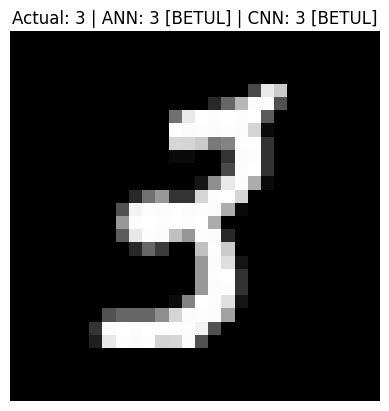

----------------------------------------
Actual: 9
ANN Prediction: 9 [BETUL]
CNN Prediction: 9 [BETUL]


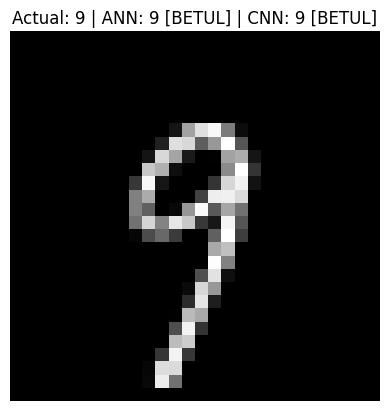

----------------------------------------
Actual: 1
ANN Prediction: 1 [BETUL]
CNN Prediction: 1 [BETUL]


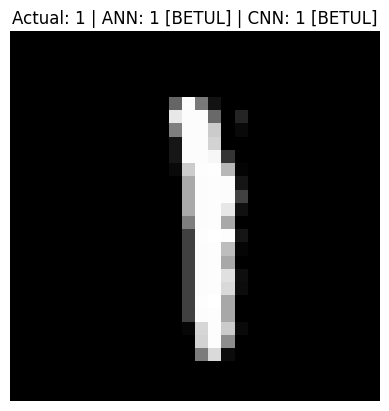

----------------------------------------
Actual: 9
ANN Prediction: 9 [BETUL]
CNN Prediction: 9 [BETUL]


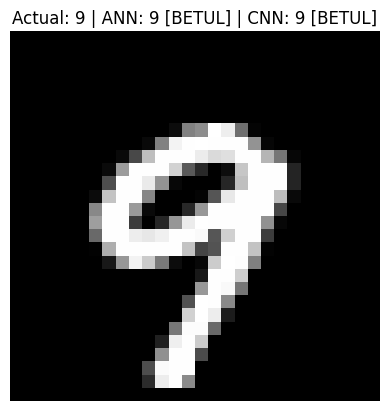

----------------------------------------
Actual: 7
ANN Prediction: 8 [SALAH]
CNN Prediction: 7 [BETUL]


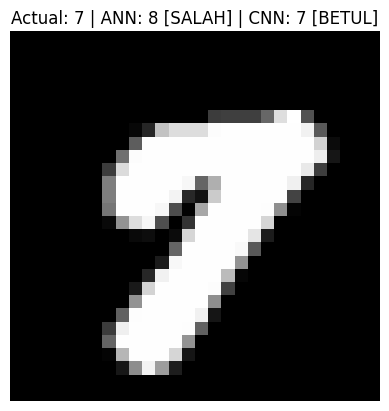

----------------------------------------


In [19]:
# Ambil 5 imej rawak dari test dataset
indices = np.random.choice(len(test_dataset), 5, replace=False)

ann_model.eval()
cnn_model.eval()
for i in indices:
    image, actual_label = test_dataset[i]
    image_batch = image.unsqueeze(0).to(device)
    # Ramalan
    with torch.no_grad():
        ann_out = ann_model(image_batch)
        cnn_out = cnn_model(image_batch)

    ann_pred = torch.argmax(ann_out, dim=1).item()
    cnn_pred = torch.argmax(cnn_out, dim=1).item()

    ann_status = "[BETUL]" if ann_pred == actual_label else "[SALAH]"
    cnn_status = "[BETUL]" if cnn_pred == actual_label else "[SALAH]"

    # Paparan teks
    print(f"Actual: {actual_label}")
    print(f"ANN Prediction: {ann_pred} {ann_status}")
    print(f"CNN Prediction: {cnn_pred} {cnn_status}")

    # Paparan imej
    plt.imshow(image.squeeze().numpy(), cmap='gray')
    plt.title(f"Actual: {actual_label} | ANN: {ann_pred} {ann_status} | CNN: {cnn_pred} {cnn_status}")
    plt.axis('off')
    plt.show()
    print("-" * 40)

### Langkah 9: Perbandingan Keputusan ANN dan CNN
Jadual di bawah merumuskan prestasi kedua-dua model. Graf bar dihasilkan untuk membandingkan testing accuracy secara visual.

MODEL      | EPOCH      | TESTING ACCURACY     | RAMALAN BETUL / 5   
-----------------------------------------------------------------
ANN        | 2          | 97.05%               | 4                   
CNN        | 2          | 98.00%               | 5                   


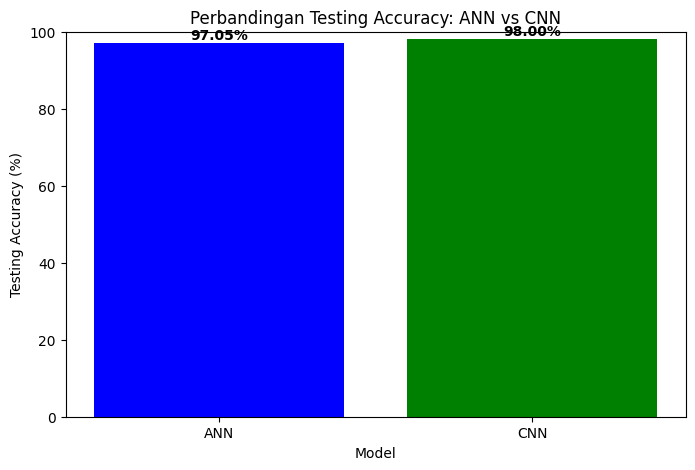

### Kesimpulan:
- Model yang memperoleh testing accuracy lebih tinggi ialah **CNN**.
- Model yang meramal lebih banyak imej betul daripada lima imej ialah **CNN**.
- CNN lazimnya lebih sesuai untuk imej.


In [26]:
# (Anggaran ramalan betul untuk 5 imej di atas - anda boleh kemaskini nilai ini berdasarkan output Langkah 8)
# Di sini saya letak placeholder, sila tukar 'ann_correct_5' dan 'cnn_correct_5' ikut output sebenar anda.
ann_correct_5 = 4
cnn_correct_5 = 5

# 1. Paparan Jadual
print(f"{'MODEL':<10} | {'EPOCH':<10} | {'TESTING ACCURACY':<20} | {'RAMALAN BETUL / 5':<20}")
print("-" * 65)
print(f"{'ANN':<10} | {'2':<10} | {f'{ann_accuracy:.2f}%':<20} | {ann_correct_5:<20}")
print(f"{'CNN':<10} | {'2':<10} | {f'{cnn_accuracy:.2f}%':<20} | {cnn_correct_5:<20}")

# 2. Hasilkan Graf Bar
models = ['ANN', 'CNN']
accuracies = [ann_accuracy, cnn_accuracy]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green'])
plt.title('Perbandingan Testing Accuracy: ANN vs CNN')
plt.xlabel('Model')
plt.ylabel('Testing Accuracy (%)')
plt.ylim(0, 100)
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

# 3, 4 & 5. Kesimpulan
better_model = "CNN" if cnn_accuracy > ann_accuracy else "ANN"
print(f"### Kesimpulan:")
print(f"- Model yang memperoleh testing accuracy lebih tinggi ialah **{better_model}**.")
print(f"- Model yang meramal lebih banyak imej betul daripada lima imej ialah **{'CNN' if cnn_correct_5 >= ann_correct_5 else 'ANN'}**.")
print(f"- CNN lazimnya lebih sesuai untuk imej.")